<a href="https://colab.research.google.com/github/Ahmednsh/ML-projects/blob/main/Heart_Disease_Prediction/heart_disease_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.ensemble import RandomForestClassifier


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# Load your dataset
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/heart.csv')  # Adjust the path as needed

# Basic data description
print("Shape of the data:", data.shape)
print("Number of features:", data.shape[1])
print("Number of samples:", data.shape[0])
print(data.describe())  # Basic statistics


Shape of the data: (918, 12)
Number of features: 12
Number of samples: 918
              Age   RestingBP  Cholesterol   FastingBS       MaxHR  \
count  918.000000  918.000000   918.000000  918.000000  918.000000   
mean    53.510893  132.396514   198.799564    0.233115  136.809368   
std      9.432617   18.514154   109.384145    0.423046   25.460334   
min     28.000000    0.000000     0.000000    0.000000   60.000000   
25%     47.000000  120.000000   173.250000    0.000000  120.000000   
50%     54.000000  130.000000   223.000000    0.000000  138.000000   
75%     60.000000  140.000000   267.000000    0.000000  156.000000   
max     77.000000  200.000000   603.000000    1.000000  202.000000   

          Oldpeak  HeartDisease  
count  918.000000    918.000000  
mean     0.887364      0.553377  
std      1.066570      0.497414  
min     -2.600000      0.000000  
25%      0.000000      0.000000  
50%      0.600000      1.000000  
75%      1.500000      1.000000  
max      6.200000     

In [ ]:
data["HeartDisease"].value_counts()

,count
HeartDisease,
1,508
0,410


In [ ]:
data

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [ ]:
data.rename(columns={'Sex_num': 'Gender_num'}, inplace=True)
data.rename(columns={'Sex': 'Gender'}, inplace=True)

In [ ]:
data.columns

Index(['Age', 'Gender', 'ChestPainType', 'RestingBP', 'Cholesterol',
       'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak',
       'ST_Slope', 'HeartDisease'],
      dtype='object')

In [ ]:
catogorical = data.dtypes[data.dtypes == object].index.tolist()
print(catogorical)

['Gender', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


In [ ]:
numerical = data.dtypes[data.dtypes != object].index.tolist()
print(numerical)

['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease']


In [ ]:
data['Gender_num'] = pd.factorize(data['Gender'])[0]
data

,Age,Gender,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,Gender_num
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1,0
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1,0
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1,0
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1,1


In [ ]:
data['ChestPainType_num'] = pd.factorize(data['ChestPainType'])[0]
data

,Age,Gender,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,Gender_num,ChestPainType_num
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0,0,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1,1,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0,0,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1,1,2
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1,0,3
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1,0,2
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1,0,2
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1,1,0


In [ ]:
data['RestingECG_num'] = pd.factorize(data['RestingECG'])[0]
data

,Age,Gender,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,Gender_num,ChestPainType_num,RestingECG_num
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0,0,0,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1,1,1,0
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0,0,0,1
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1,1,2,0
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1,0,3,0
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1,0,2,0
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1,0,2,0
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1,1,0,2


In [ ]:
data['ExerciseAngina_num'] = pd.factorize(data['ExerciseAngina'])[0]
data

,Age,Gender,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,Gender_num,ChestPainType_num,RestingECG_num,ExerciseAngina_num
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0,0,0,0,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1,1,1,0,0
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0,0,0,1,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1,1,2,0,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1,0,3,0,0
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1,0,2,0,0
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1,0,2,0,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1,1,0,2,0


In [ ]:
data['ST_Slope_num'] = pd.factorize(data['ST_Slope'])[0]
data

,Age,Gender,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,Gender_num,ChestPainType_num,RestingECG_num,ExerciseAngina_num,ST_Slope_num
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0,0,0,0,0,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1,1,1,0,0,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0,0,0,1,0,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1,1,2,0,1,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1,0,3,0,0,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1,0,2,0,0,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1,0,2,0,1,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1,1,0,2,0,1


In [ ]:
columns_to_remove = ['Gender', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
new_data = data.drop(columns_to_remove, axis=1, inplace=True)

In [ ]:
print(data)

     Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  HeartDisease  \
0     40        140          289          0    172      0.0             0   
1     49        160          180          0    156      1.0             1   
2     37        130          283          0     98      0.0             0   
3     48        138          214          0    108      1.5             1   
4     54        150          195          0    122      0.0             0   
..   ...        ...          ...        ...    ...      ...           ...   
913   45        110          264          0    132      1.2             1   
914   68        144          193          1    141      3.4             1   
915   57        130          131          0    115      1.2             1   
916   57        130          236          0    174      0.0             1   
917   38        138          175          0    173      0.0             0   

     Gender_num  ChestPainType_num  RestingECG_num  ExerciseAngina_num  \
0

In [ ]:
data.isna().any()

,0
Age,False
RestingBP,False
Cholesterol,False
FastingBS,False
MaxHR,False
Oldpeak,False
HeartDisease,False
Gender_num,False
ChestPainType_num,False
RestingECG_num,False


In [ ]:
data.duplicated().any()

np.False_

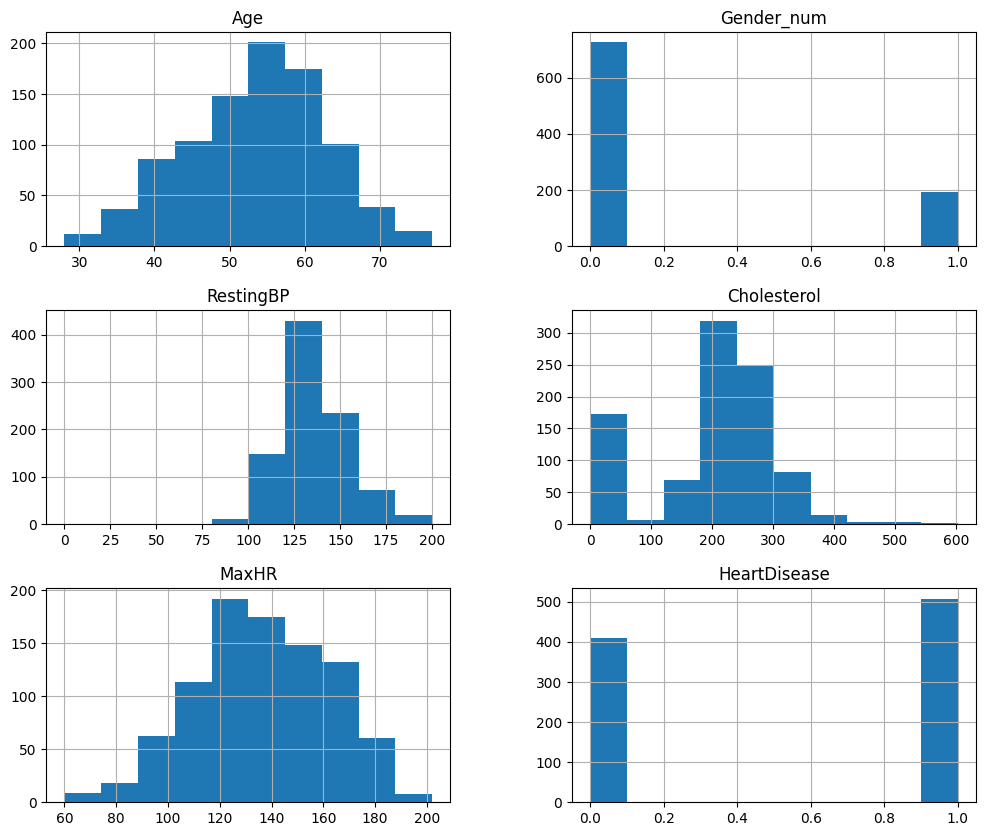

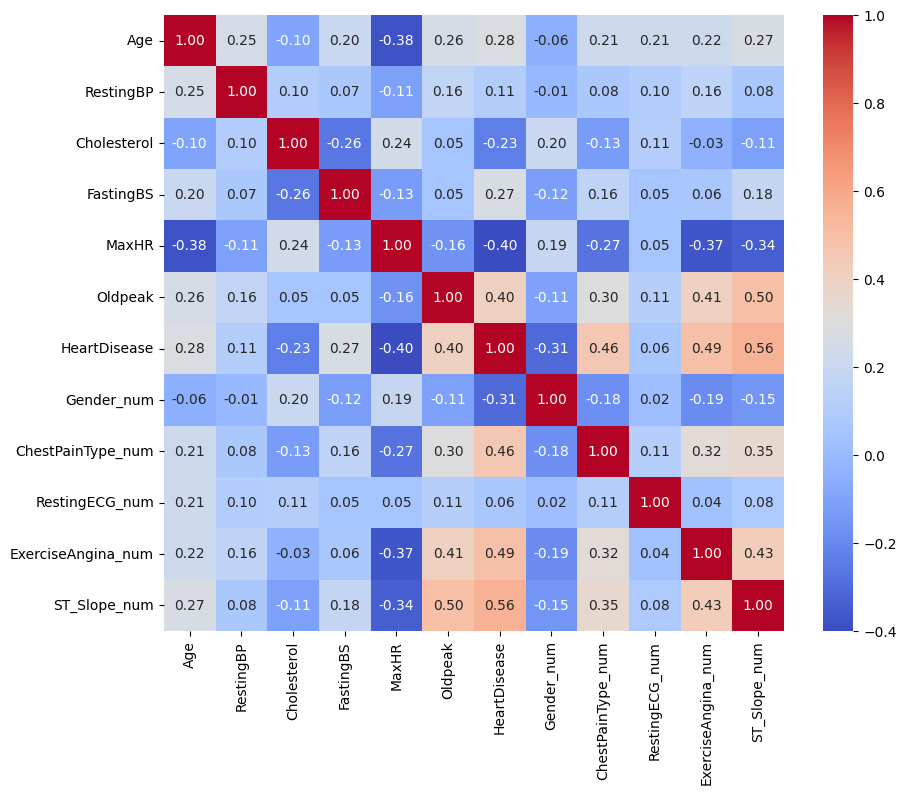

In [ ]:
# Histograms for each feature
data[['Age','Gender_num', 'RestingBP', 'Cholesterol', 'MaxHR', 'HeartDisease']].hist(figsize=(12, 10))
plt.show()

# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.show()


In [ ]:
data.columns

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease', 'Gender_num', 'ChestPainType_num', 'RestingECG_num',
       'ExerciseAngina_num', 'ST_Slope_num'],
      dtype='object')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 918 non-null    int64  
 1   RestingBP           918 non-null    int64  
 2   Cholesterol         918 non-null    int64  
 3   FastingBS           918 non-null    int64  
 4   MaxHR               918 non-null    int64  
 5   Oldpeak             918 non-null    float64
 6   HeartDisease        918 non-null    int64  
 7   Gender_num          918 non-null    int64  
 8   ChestPainType_num   918 non-null    int64  
 9   RestingECG_num      918 non-null    int64  
 10  ExerciseAngina_num  918 non-null    int64  
 11  ST_Slope_num        918 non-null    int64  
dtypes: float64(1), int64(11)
memory usage: 86.2 KB


In [ ]:
# Using Min-Max Scaler
scaler = MinMaxScaler()
# Fit the scaler on the features only (excluding 'HeartDisease')
data_scaled = pd.DataFrame(scaler.fit_transform(data.drop('HeartDisease', axis=1)), columns=data.drop('HeartDisease', axis=1).columns)
data_scaled

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Gender_num,ChestPainType_num,RestingECG_num,ExerciseAngina_num,ST_Slope_num
0,0.244898,0.70,0.479270,0.0,0.788732,0.295455,0.0,0.000000,0.0,0.0,0.0
1,0.428571,0.80,0.298507,0.0,0.676056,0.409091,1.0,0.333333,0.0,0.0,0.5
2,0.183673,0.65,0.469320,0.0,0.267606,0.295455,0.0,0.000000,0.5,0.0,0.0
3,0.408163,0.69,0.354892,0.0,0.338028,0.465909,1.0,0.666667,0.0,1.0,0.5
4,0.530612,0.75,0.323383,0.0,0.436620,0.295455,0.0,0.333333,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
913,0.346939,0.55,0.437811,0.0,0.507042,0.431818,0.0,1.000000,0.0,0.0,0.5
914,0.816327,0.72,0.320066,1.0,0.570423,0.681818,0.0,0.666667,0.0,0.0,0.5
915,0.591837,0.65,0.217247,0.0,0.387324,0.431818,0.0,0.666667,0.0,1.0,0.5
916,0.591837,0.65,0.391376,0.0,0.802817,0.295455,1.0,0.000000,1.0,0.0,0.5


In [ ]:
# Initialize classifiers with the specified parameters
dt_clf = DecisionTreeClassifier(max_depth=4, min_samples_split=276, criterion='gini')
svm_clf = SVC(kernel='linear')
gnb_clf = GaussianNB()
bnb_clf = BernoulliNB()
rf_clf = RandomForestClassifier()

# Define a dictionary to hold classifiers
classifiers = {
    "Decision Tree": dt_clf,
    "SVM": svm_clf,
    "Gaussian Naive Bayes": gnb_clf,
    "Bernoulli Naive Bayes": bnb_clf,
    "Random Forest": rf_clf  # Parameters will be tuned later using RandomizedSearchCV
}


In [ ]:
# Assuming 'label' is the target variable
X = data_scaled
y = data['HeartDisease']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Decision Tree Accuracy: 0.80, F1 Score: 0.80


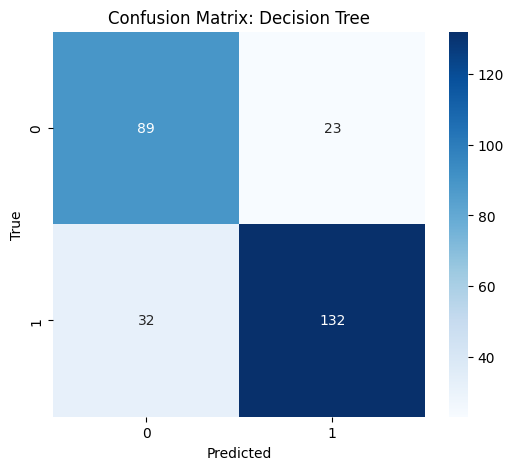

SVM Accuracy: 0.87, F1 Score: 0.87


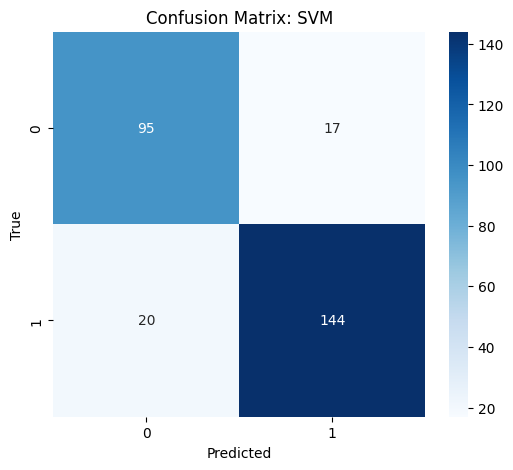

Gaussian Naive Bayes Accuracy: 0.87, F1 Score: 0.87


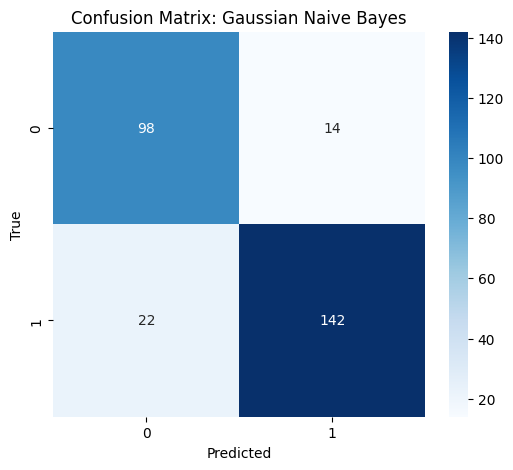

Bernoulli Naive Bayes Accuracy: 0.90, F1 Score: 0.90


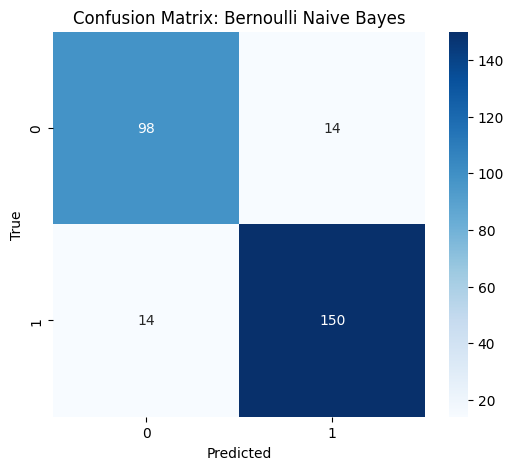

Random Forest Accuracy: 0.88, F1 Score: 0.88


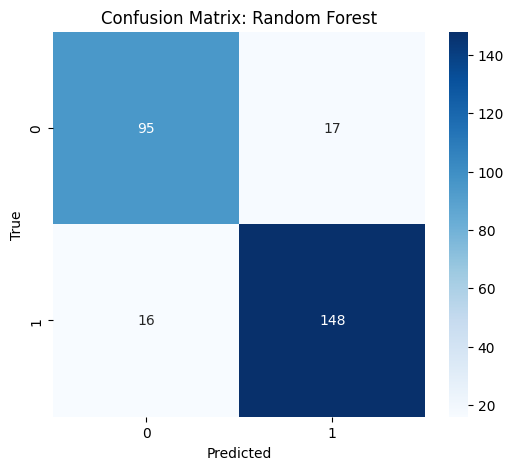

In [ ]:
# Train and evaluate each classifier
for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    print(f"{name} Accuracy: {acc:.2f}, F1 Score: {f1:.2f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap='Blues')
    plt.title(f'Confusion Matrix: {name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()


Decision Tree Accuracy: 0.80, F1 Score: 0.80


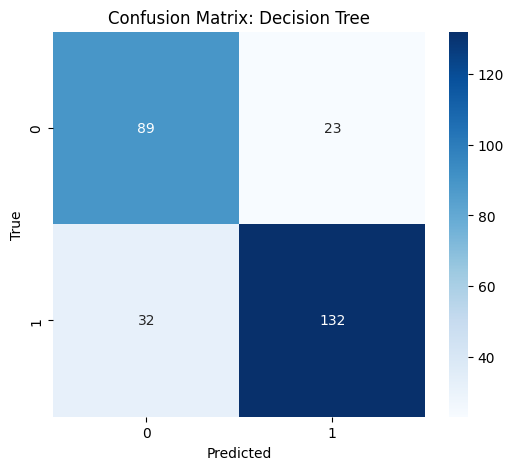

SVM Accuracy: 0.87, F1 Score: 0.87


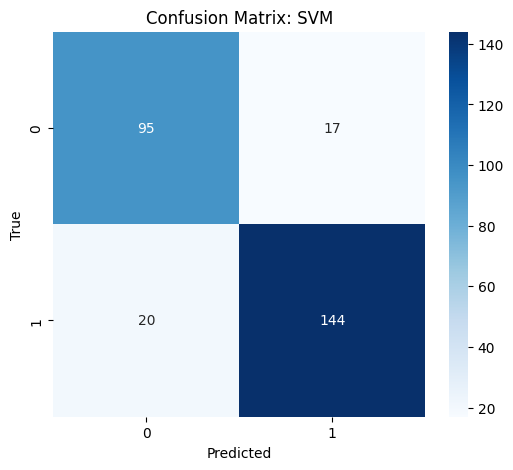

Gaussian Naive Bayes Accuracy: 0.87, F1 Score: 0.87


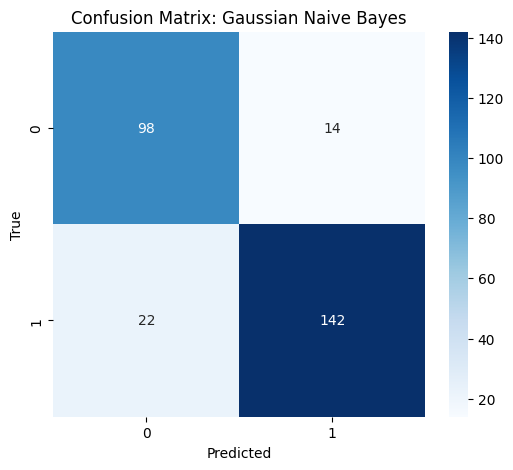

Bernoulli Naive Bayes Accuracy: 0.90, F1 Score: 0.90


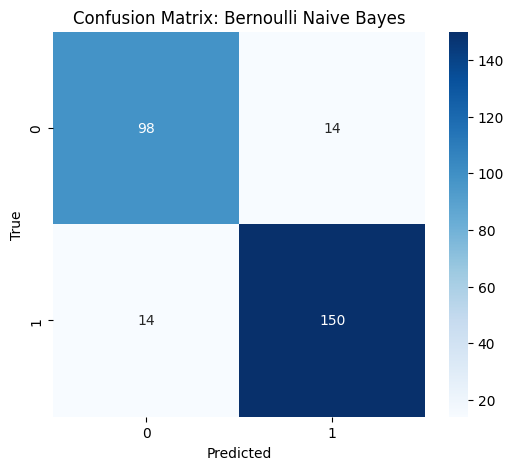

Random Forest Accuracy: 0.88, F1 Score: 0.88


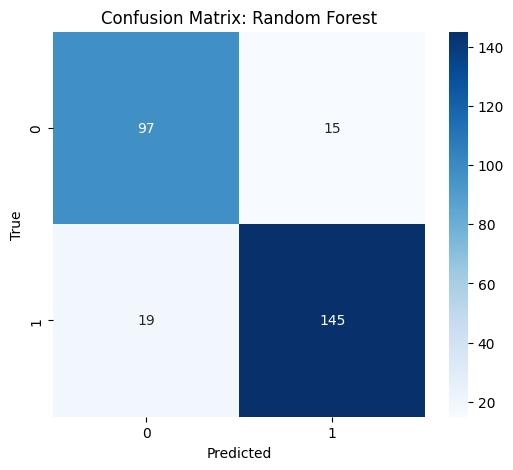

/tmp/ipython-input-1390288230.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=accuracies, y=classifier_names, palette='Blues_d')


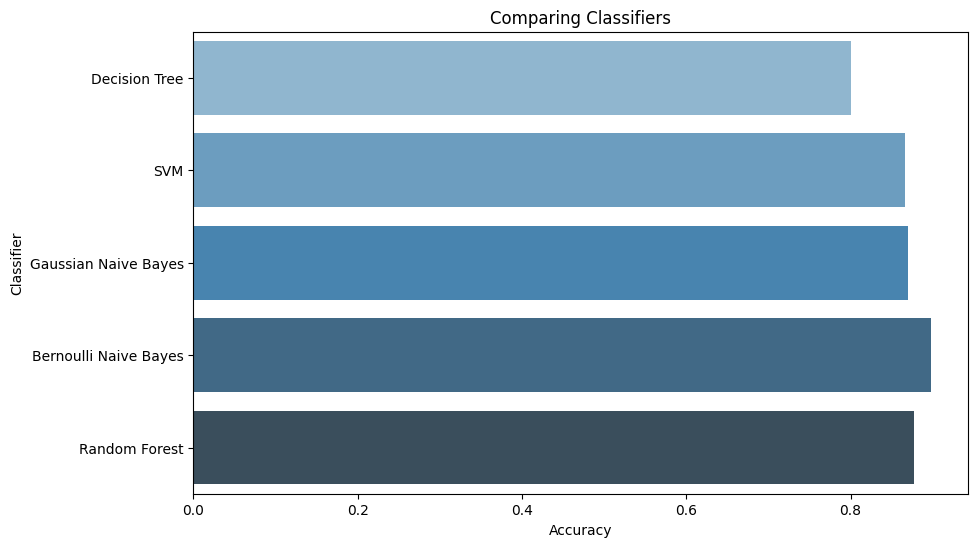

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

classifier_names = []
accuracies = []

for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    print(f"{name} Accuracy: {acc:.2f}, F1 Score: {f1:.2f}")

    classifier_names.append(name)
    accuracies.append(acc)

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap='Blues')
    plt.title(f'Confusion Matrix: {name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x=accuracies, y=classifier_names, palette='Blues_d')
plt.title('Comparing Classifiers')
plt.xlabel('Accuracy')
plt.ylabel('Classifier')
plt.show()


In [ ]:
import joblib

joblib.dump(bnb_clf, '/content/drive/MyDrive/Colab Notebooks/models/project_model.pkl')

['/content/drive/MyDrive/Colab Notebooks/models/project_model.pkl']

In [ ]:
import joblib

model = joblib.load('/content/drive/MyDrive/Colab Notebooks/models/random_forest_model.pkl')

In [ ]:
from pickle import INT
import pandas as pd # Import pandas
import joblib

print("enter the following data")

# Get input values from the user
Age = float(input("Age: "))
RestingBP = float(input("RestingBP: "))
Cholesterol = float(input("Cholesterol: "))
FastingBS = float(input("FastingBS: "))
MaxHR = float(input("MaxHR: "))
Oldpeak = float(input("Oldpeak: "))
Gender_str = input("Gender (M/F): ")
ChestPainType_str = input("ChestPainType (ATA, NAP, ASY, TA): ")
RestingECG_str = input("RestingECG (Normal, ST, LVH): ")
ExerciseAngina_str = input("ExerciseAngina (Y/N): ")
ST_Slope_str = input("ST_Slope (Up, Flat, Down): ")


# Load the original data to access original categorical columns for factorization
# Make sure the path to the original heart.csv is correct
original_data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/heart.csv")

# Use the same factorization as before to convert categorical strings to numeric
def get_numeric_factor(input_str, original_series):
    if not input_str:
        # Handle empty input if necessary, perhaps return a default value or raise an error
        return -1 # Placeholder for not found or empty
    # Ensure original_series is a pandas Series
    if not isinstance(original_series, pd.Series):
        print(f"Warning: Expected a pandas Series for factorization, but got {type(original_series)}")
        # Fallback or error handling for incorrect input type
        return -1 # Placeholder or error
    unique_values = pd.factorize(original_series)[1]
    try:
        # Use get_loc for potential performance benefits with Index objects
        return unique_values.get_loc(input_str)
    except KeyError:
        # Handle cases where the input string is not in the original data's unique values
        print(f"Warning: Input value '{input_str}' not found in original data's unique values for column.")
        return -1 # Placeholder for not found

Gender_num = get_numeric_factor(Gender_str, original_data['Sex'])
ChestPainType_num = get_numeric_factor(ChestPainType_str, original_data['ChestPainType'])
RestingECG_num = get_numeric_factor(RestingECG_str, original_data['RestingECG'])
ExerciseAngina_num = get_numeric_factor(ExerciseAngina_str, original_data['ExerciseAngina'])
ST_Slope_num = get_numeric_factor(ST_Slope_str, original_data['ST_Slope'])


# Create DataFrame for the inputs - ensure column names match the training data features excluding 'HeartDisease'
user_input = pd.DataFrame([[Age, RestingBP, Cholesterol, FastingBS, MaxHR, Oldpeak, Gender_num, ChestPainType_num, RestingECG_num, ExerciseAngina_num, ST_Slope_num]],
                          columns=['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
                                   'Gender_num', 'ChestPainType_num', 'RestingECG_num', 'ExerciseAngina_num', 'ST_Slope_num'])


# Scale the user input using the same scaler used for training
# Ensure the 'scaler' object is available in the environment from the training cells
if 'scaler' in locals() and scaler is not None:
    # Use scaler to transform the user input DataFrame
    user_input_scaled = scaler.transform(user_input)
else:
    print("Error: Scaler not found. Please run the cell that trains and saves the scaler (eFQFtS0DnVg1).")
    user_input_scaled = None # Set to None or handle as appropriate

# Load the saved model
# Ensure the path to your saved model is correct
model_path = '/content/drive/MyDrive/Colab Notebooks/models/project_model.pkl' # Assuming this is the path to your saved BernoulliNB model
try:
    model = joblib.load(model_path)
except FileNotFoundError:
    print(f"Error: Model not found at {model_path}. Please check the path or train and save the model.")
    model = None

# Predict the HeartDisease
if user_input_scaled is not None and model is not None:
    prediction = model.predict(user_input_scaled)[0]

    # Assuming the prediction is directly the HeartDisease value (0 or 1)
    predicted_HeartDisease = prediction

    print(f"\n Predicted HeartDisease: {predicted_HeartDisease}")
else:
    print("Error: Model not found or input scaling failed. Prediction cannot be made.")

enter the following data
Age: 48
RestingBP: 138
Cholesterol: 214
FastingBS: 0
MaxHR: 108
Oldpeak: 1.5
Gender (M/F): F
ChestPainType (ATA, NAP, ASY, TA): ASY
RestingECG (Normal, ST, LVH): Normal
ExerciseAngina (Y/N): Y
ST_Slope (Up, Flat, Down): Flat

 Predicted HeartDisease: 1


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but BernoulliNB was fitted with feature names
  warnings.warn(
